## Import & Parameter

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Ensure scikit-image is available for SSIM-NET simulation
try:
    from skimage.metrics import structural_similarity as ssim
except ImportError:
    # Fallback message to assist in setting up the environment
    raise ImportError("Please install scikit-image using: pip install scikit-image")

# Set up global parameters for comparison algorithm input requirements
TARGET_SIZE = (224, 224) # Standard input size for LPViT, ResNet, MobileNet, and AlexNet
PIXELS_PER_MM = 15.0     # Default spatial calibration factor

print("✅ Initialization complete. Target patch dimension set to:", TARGET_SIZE)

✅ Initialization complete. Target patch dimension set to: (224, 224)


## Load Preprocessed Dataset

📊 Dataset Statistics:
-----------------------------------------------------------------
ID 0 | Missing_hole     | Count: 568   | 16.9%
ID 1 | Mouse_bite       | Count: 560   | 16.7%
ID 2 | Open_circuit     | Count: 535   | 15.9%
ID 3 | Short            | Count: 551   | 16.4%
ID 4 | Spur             | Count: 566   | 16.9%
ID 5 | Spurious_copper  | Count: 575   | 17.1%

✅ DataLoaders Ready. Device: cpu
✅ Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
✅ Training Samples: 3355
✅ Validation Samples: 467
✅ Test Samples: 607


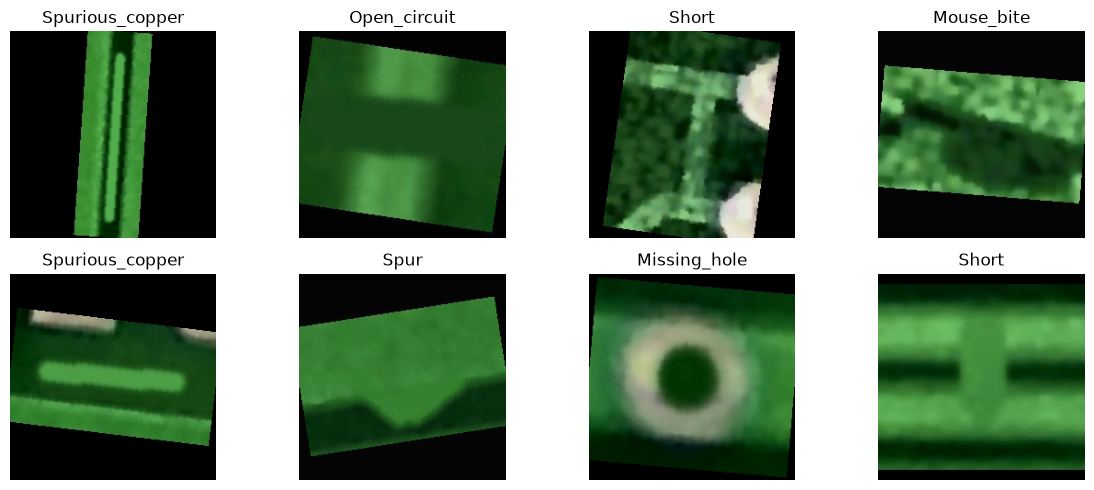

In [18]:
# ==============================================================================
# PHASE 2: DATALOADERS CREATION (OPTIMIZED FOR PCB DEFECTS)
# ==============================================================================
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Transforms ---
# We keep online augmentation light because Offline augmentation is already done.
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), # Reduced slightly to avoid excessive warping
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Micro-adjustments
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. Load Datasets ---
PROCESSED_DIR = "dataset_processed"
train_dataset = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "val"),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(root=os.path.join(PROCESSED_DIR, "test"),  transform=eval_transforms)

# --- 3. Compute Sampling Weights for Better Class Balance ---
targets = train_dataset.targets
class_count = np.unique(targets, return_counts=True)[1]

# Weight for each SAMPLE in the training set
weight = 1. / class_count
samples_weight = torch.from_numpy(weight[targets])
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

# --- 4. Instantiate DataLoaders ---
BATCH_SIZE = 32

# Use sampler for train_loader instead of shuffle=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# --- 5. Verify & Compute Loss Weights (Backup Strategy) ---
print("📊 Dataset Statistics:")
print("-" * 65)

total = len(train_dataset)
class_weights = []

for idx, class_name in enumerate(train_dataset.classes):
    count = (np.array(targets) == idx).sum()
    print(f"ID {idx} | {class_name:<16} | Count: {count:<5} | {100*count/total:.1f}%")
    class_weights.append(total / (len(train_dataset.classes) * count))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# --- 6. Store Class Names ---
class_names = list(val_dataset.classes)

print(f"\n✅ DataLoaders Ready. Device: {device}")
print(f"✅ Classes: {class_names}")
print(f"✅ Training Samples: {len(train_dataset)}")
print(f"✅ Validation Samples: {len(val_dataset)}")
print(f"✅ Test Samples: {len(test_dataset)}")

# --- 7. VISUALIZATION CHECK ---
def show_batch(dl):
    img_batch, label_batch = next(iter(dl))
    plt.figure(figsize=(12, 5))
    
    for i in range(8):
        plt.subplot(2, 4, i+1)
        
        # Un-normalize for visualization
        img = img_batch[i].numpy().transpose((1, 2, 0))
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        
        plt.imshow(img)
        plt.title(train_dataset.classes[label_batch[i]])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [19]:
# ============================================================
# OOD Reference Generation
# ============================================================

import torch
import torch.nn as nn
import numpy as np
from pathlib import Path

OOD_OUTPUT_PATH = Path("ood_reference_alexnet.pth")

OOD_PERCENTILE = 95

In [20]:
# ============================================================
# AlexNet Model Definition
# ============================================================

import torch.nn as nn
import torchvision.models as models

def get_alexnet(num_classes=6, dropout_p=0.5):
    model = models.alexnet(weights=None)
    model.classifier[2].p = dropout_p
    model.classifier[5].p = dropout_p
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    
    return model

print("✅ AlexNet model definition ready.")

✅ AlexNet model definition ready.


In [21]:
# ============================================================
# Load Best AlexNet
# ============================================================

checkpoint = torch.load(
    "Exported_Models/AlexNet_-_HPO-Tuned.pth",
    map_location=device,
    weights_only=False
)

params = checkpoint.get("hpo_best_params") or {}

if isinstance(params, dict):
    nested = params.get("AlexNet (Auto-VRS)")
    if isinstance(nested, dict):
        params = nested
else:
    params = {}

dropout_p = float(params.get("dropout_p", 0.5))

ood_model = get_alexnet(
    num_classes=len(class_names),
    dropout_p=dropout_p
)

state_dict = {
    key: value
    for key, value in checkpoint["state_dict"].items()
    if not key.endswith("total_ops")
    and not key.endswith("total_params")
}

ood_model.load_state_dict(
    state_dict,
    strict=True
)

ood_model = ood_model.to(device)
ood_model.eval()

print("✅ AlexNet loaded successfully.")
print("✅ Model:", checkpoint["model_name"])
print("✅ Dropout:", dropout_p)

✅ AlexNet loaded successfully.
✅ Model: AlexNet - HPO-Tuned
✅ Dropout: 0.3125031598975946


In [22]:
# ============================================================
# Create AlexNet Feature Extractor
# ============================================================

class AlexNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.avgpool = model.avgpool
        self.classifier = nn.Sequential(
            *list(model.classifier.children())[:-1]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        
        return x

feature_extractor = AlexNetFeatureExtractor(
    ood_model
).to(device)

feature_extractor.eval()

print("✅ AlexNet feature extractor created.")

✅ AlexNet feature extractor created.


In [23]:
sample_images, _ = next(iter(val_loader))

with torch.inference_mode():
    sample_features = feature_extractor(
        sample_images[:1].to(device)
    )

print("Feature shape:", sample_features.shape)

Feature shape: torch.Size([1, 4096])


In [24]:
# ============================================================
# Extract Validation Features
# ============================================================

features_by_class = {
    class_name: []
    for class_name in class_names
}

with torch.inference_mode():

    for images, labels in val_loader:

        images = images.to(
            device
        )

        features = feature_extractor(
            images
        )

        features = torch.flatten(
            features,
            1
        )

        features = features.cpu().numpy()

        labels = labels.cpu().numpy()

        for feature, label in zip(
            features,
            labels
        ):
            class_name = class_names[
                int(label)
            ]

            features_by_class[
                class_name
            ].append(
                feature
            )

print(
    "Feature extraction completed."
)

Feature extraction completed.


In [25]:
# ============================================================
# Check Extracted Samples
# ============================================================

for class_name in class_names:
    print(
        class_name,
        ":",
        len(
            features_by_class[
                class_name
            ]
        ),
        "samples"
    )

Missing_hole : 78 samples
Mouse_bite : 76 samples
Open_circuit : 81 samples
Short : 75 samples
Spur : 75 samples
Spurious_copper : 82 samples


In [ ]:
# ============================================================
# Calculate Class Centres
# ============================================================

class_centres = {}

for class_name in class_names:
    class_features = np.array(
        features_by_class[class_name]
    )

    class_centres[class_name] = np.mean(
        class_features,
        axis=0
    )

print("✅ Class centres calculated.")

for class_name in class_names:
    print(
        class_name,
        ":",
        class_centres[class_name].shape
    )

Missing_hole centre calculated.
Mouse_bite centre calculated.
Open_circuit centre calculated.
Short centre calculated.
Spur centre calculated.
Spurious_copper centre calculated.


In [26]:
# ============================================================
# Calculate Feature Distances
# ============================================================

distances_by_class = {}

for class_name in class_names:

    class_features = np.array(
        features_by_class[
            class_name
        ]
    )

    class_centre = class_centres[
        class_name
    ]

    distances = np.linalg.norm(
        class_features - class_centre,
        axis = 1
    )

    distances_by_class[
        class_name
    ] = distances

    print(
        class_name,
        "- Mean distance:",
        round(
            float(
                np.mean(distances)
            ),
            4
        )
    )

ValueError: operands could not be broadcast together with shapes (78,4096) (512,) 

In [14]:
# ============================================================
# Calculate OOD Thresholds
# ============================================================

class_thresholds = {}

for class_name in class_names:

    distances = distances_by_class[
        class_name
    ]

    threshold = np.percentile(
        distances,
        OOD_PERCENTILE
    )

    class_thresholds[
        class_name
    ] = float(
        threshold
    )

    print(
        class_name,
        "- OOD threshold:",
        round(
            float(threshold),
            4
        )
    )

Missing_hole - OOD threshold: 4.9902
Mouse_bite - OOD threshold: 9.4843
Open_circuit - OOD threshold: 7.891
Short - OOD threshold: 8.0165
Spur - OOD threshold: 7.49
Spurious_copper - OOD threshold: 8.8074


In [ ]:
print("Feature dimension:", feature_dimension)

if feature_dimension != 4096:
    print("⚠ Warning: Unexpected AlexNet feature dimension.")

In [ ]:
# ============================================================
# Save OOD Reference
# ============================================================

feature_dimension = len(
    features_by_class[class_names[0]][0]
)

ood_reference = {
    "class_names": class_names,
    "class_centres": {
        class_name: torch.tensor(class_centres[class_name], dtype=torch.float32)
        for class_name in class_names
    },
    "class_thresholds": class_thresholds,
    "percentile": OOD_PERCENTILE,
    "feature_dimension": feature_dimension
}

torch.save(ood_reference, OOD_OUTPUT_PATH)

print("OOD reference saved to:", OOD_OUTPUT_PATH)
print("Feature dimension:", feature_dimension)

OOD reference saved to: ood_reference.pth


In [16]:
# ============================================================
# Verify OOD Reference
# ============================================================

saved_ood = torch.load(
    OOD_OUTPUT_PATH,
    map_location="cpu",
    weights_only=False
)

print("Classes:", saved_ood["class_names"])
print("\nFeature dimension:", saved_ood["feature_dimension"])
print("\nOOD percentile:", saved_ood["percentile"])
print("\nClass thresholds:")

for class_name in saved_ood["class_names"]:
    print(class_name, ":", round(saved_ood["class_thresholds"][class_name], 4))

Classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']

Feature dimension: 512

OOD percentile: 95

Class thresholds:
Missing_hole : 4.9902
Mouse_bite : 9.4843
Open_circuit : 7.891
Short : 8.0165
Spur : 7.49
Spurious_copper : 8.8074
